# Comparaison et exploration des méthodes de régression et de classification
Ce notebook est organisé en **trois parties indépendantes** :
1. **Comparaison MCO/BIC/AIC** en régression (données ozone, validation croisée)
2. **Exploration des chemins de régularisation** Lasso/Ridge/ElasticNet (données ozone, pédagogie)
3. **Exploration de la régression logistique** (données SAh, sélection de variables + sklearn)

# Partie 1 — Comparaison MCO / BIC / AIC en régression
**Données** : `ozone_transf.txt` (variables qualitatives déjà encodées, cible = `maxO3`)  
**Méthode** : validation croisée par blocs aléatoires (10 blocs)  
**Objectif** : comparer les MSE de 3 approches de régression linéaire

**But de cette partie :** comparer les différentes méthodes de régression vues jusqu'à présent — moindres carrés (MCO), sélection backward selon BIC, sélection backward selon AIC.

La validation croisée utilise $k = 10$ blocs (paramètre modifiable). Les données s'appellent `don`, la variable cible est `Y` (renommée depuis `maxO3`).

In [ ]:
import pandas as pd; import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from patsy import dmatrix
import ols_step_sk

In [ ]:

don = pd.read_csv("https://regression-avec-python.github.io/donnees/ozone.txt", header=0, sep=";",index_col=0)
don.describe(include='all')

,O3,T12,T15,Ne12,N12,S12,E12,W12,Vx,O3v,nebu,vent
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.00000,50.000000,50,50
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,4
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NUAGE,OUEST
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28,18
mean,86.300000,20.320000,21.390000,5.020000,0.940000,0.580000,1.360000,1.540000,-0.83120,84.280000,NaN,NaN
std,23.900824,4.674638,4.980544,2.535382,2.122859,1.499524,2.229304,2.451239,13.59233,24.953868,NaN,NaN
min,41.800000,7.900000,10.100000,0.000000,0.000000,0.000000,0.000000,0.000000,-27.06000,38.000000,NaN,NaN
25%,66.600000,17.400000,18.150000,3.000000,0.000000,0.000000,0.000000,0.000000,-10.80000,63.400000,NaN,NaN
50%,83.900000,19.750000,21.050000,6.000000,0.000000,0.000000,0.000000,0.000000,-3.25500,83.400000,NaN,NaN
75%,102.200000,24.325000,25.700000,7.000000,0.000000,0.000000,3.000000,2.750000,9.35000,102.750000,NaN,NaN


Codage des variables qualitatives nebu et vent

In [ ]:
don = pd.read_csv("https://regression-avec-python.github.io/donnees/ozone_transf.txt", header = 0, sep = ";", index_col=0)
print(don.shape)
don.rename(columns={"maxO3":"Y"},inplace=True)


(1366, 22)


Mise en forme de X et Y

In [ ]:
# renommage de O3 en Y dans le df don
don.rename(columns={"O3":"Y"},inplace=True)

# récupère toutes les colonnes de don sauf Y => les précicteursX
nomsvar = list(don.columns.difference(["Y"]))

# design matrix : encodage des variables catégorielles
formule = "~" + "+".join(nomsvar)       # crée une formule de type R/Patsy, ex. : "~X1+X2+X3" qui signifie Y est expliqué par X1, X2 et X3"
dsX = dmatrix(formule,don)

# création des tableaux X et Y
X = np.asarray(dsX)[:,1:]       # conversion de la matrice en tableau Numpy et supprime la 1er colonne intercept qui avait été ajoutée automatiquement par patsy
Y = don["Y"].to_numpy()         # extraction de la variable dépendante Y sous forme de tbleau Numpy

Préparation de la Validation croisée en K-folds (ici K = 10)

In [ ]:
# on découpe en 10 groupes de taille égale
nb=10           
# np.arange : génèration d'un séquence, chaque observation reçoit une étiquette entre 0 et 9, distribuée de façon cyclique (%nb est le modulo K)
tmp = np.arange(don.shape[0])%nb        
# mélange aléatoire des étiquettes
rng = np.random.default_rng(seed=1234)                  # crée un générateur aléatoire reproductible (le seed garantit qu'on obtient toujours le même mélange)
bloc = rng.choice(tmp,size=don.shape[0],replace=False)  # mélange aléatoirement les étiquettes [0..9] sans remise

# création du tableau de résultats - stocke les prévisions de chaque modèle
PREV = pd.DataFrame({"bloc":bloc,"Y":don["Y"],"MCO":0.0,"BIC":0.0,"AIC":0.0})

Lancement de la boucle de validation croisée

In [ ]:
for i in np.arange(nb):
    print(i)
    Xapp = X[bloc!=i,:]         # lignes dont le bloc ≠ i  → apprentissage (90%)
    Xtest = X[bloc==i,:]        # lignes dont le bloc = i  → test (10%)
    Yapp = don[bloc!=i]["Y"]
    Ytest = don[bloc==i]["Y"]
    #### reg
    reg = LinearRegression()
    reg.fit(Xapp,Yapp)
    PREV.loc[PREV.bloc==i,"MCO"] = reg.predict(Xtest)
    ### bic
    inst_reg_bic = ols_step_sk.LinearRegressionSelectionFeatureIC(verbose=1,crit="bic")
    reg_bic = inst_reg_bic.fit(X=Xapp, y=Yapp)
    PREV.loc[PREV.bloc==i,"BIC"] = reg_bic.predict(Xtest)
    ### aic
    inst_reg_aic = ols_step_sk.LinearRegressionSelectionFeatureIC(verbose=1,crit="aic")
    reg_aic = inst_reg_aic.fit(X=Xapp, y=Yapp)
    PREV.loc[PREV.bloc==i,"AIC"] = reg_aic.predict(Xtest)

0
Final: [0, 4, 5, 8, 11, 20]
Final: [0, 4, 5, 6, 8, 11, 18, 19, 20]
1
Final: [0, 4, 5, 8, 10, 20]
Final: [0, 4, 5, 6, 8, 10, 11, 12, 19, 20]
2
Final: [0, 5, 8, 11, 20]
Final: [0, 4, 5, 6, 8, 11, 12, 13, 20]
3
Final: [0, 4, 5, 8, 11, 20]
Final: [0, 4, 5, 6, 8, 11, 12, 18, 19, 20]
4
Final: [0, 5, 8, 10, 20]
Final: [0, 4, 5, 6, 8, 10, 20]
5
Final: [0, 5, 8, 10, 20]
Final: [0, 4, 5, 6, 8, 10, 18, 19, 20]
6
Final: [0, 5, 8, 10, 20]
Final: [0, 1, 4, 5, 8, 10, 11, 12, 15, 19, 20]
7
Final: [0, 5, 8, 10, 20]
Final: [0, 1, 4, 5, 8, 10, 11, 12, 15, 19, 20]
8
Final: [0, 5, 8, 10, 20]
Final: [0, 1, 4, 5, 8, 10, 19, 20]
9
Final: [0, 5, 8, 11, 20]
Final: [0, 4, 5, 6, 8, 11, 12, 18, 19, 20]


In [39]:
prev = PREV.iloc[:,1:]
np.round((prev.sub(PREV.Y, axis=0)**2).mean(),2)

Y        0.00
MCO    187.51
BIC    188.23
AIC    187.74
dtype: float64

# Partie 2 — Exploration des chemins de régularisation (Lasso / Ridge / ElasticNet)
**Données** : `ozone.txt` (données brutes, sans transformation)  
**Objectif pédagogique** : visualiser comment les coefficients évoluent en fonction de $\lambda$ (`alpha` dans sklearn)  
> ⚠️ Cette partie est exploratoire : on fait varier manuellement la grille d'`alpha` pour mieux comprendre le comportement des pénalités. Ce n'est pas la procédure opérationnelle (qui utilise la CV).

La régularisation pénalise les coefficients pour réduire la variance du modèle. Le paramètre $\lambda$ (nommé `alpha` dans sklearn) contrôle l'intensité de la pénalité :
- $\lambda$ grand → coefficients très réduits (modèle simple)
- $\lambda$ petit → proche des MCO (modèle complexe)

On commence par laisser `LassoCV` choisir automatiquement une grille, puis on explore manuellement différentes grilles pour comprendre la forme des **chemins de régularisation** (coefficient en fonction de $\lambda$).

In [40]:
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, ElasticNet, Lasso
from sklearn.linear_model import RidgeCV, ElasticNetCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold

In [42]:
ozone = pd.read_csv("https://regression-avec-python.github.io/donnees/ozone.txt", header = 0, sep = ";", index_col=0)
X = ozone.iloc[:,1:10].to_numpy()
y = ozone["O3"].to_numpy()

Il faut centrer réduire

In [43]:
cr = StandardScaler()

In [ ]:
# Étape 1 : LassoCV détermine automatiquement la grille d'alpha par CV 10 blocs
# Le Pipeline garantit que StandardScaler est appliqué avant le Lasso
lassocv = LassoCV(cv=10, random_state=0)
pipe_lassocv = Pipeline(steps=[("cr", cr), ("lassocv", lassocv)])
pipe_lassocv.fit(X, y)
etape_lassocv = pipe_lassocv.named_steps["lassocv"]
etape_lassocv.alphas_   # liste des alpha testés par LassoCV

array([1.82214402e+01, 1.69933761e+01, 1.58480794e+01, 1.47799719e+01,
       1.37838513e+01, 1.28548658e+01, 1.19884909e+01, 1.11805068e+01,
       1.04269780e+01, 9.72423459e+00, 9.06885373e+00, 8.45764334e+00,
       7.88762649e+00, 7.35602686e+00, 6.86025527e+00, 6.39789702e+00,
       5.96670018e+00, 5.56456456e+00, 5.18953153e+00, 4.83977447e+00,
       4.51358987e+00, 4.20938902e+00, 3.92569029e+00, 3.66111190e+00,
       3.41436521e+00, 3.18424843e+00, 2.96964074e+00, 2.76949689e+00,
       2.58284207e+00, 2.40876716e+00, 2.24642431e+00, 2.09502283e+00,
       1.95382531e+00, 1.82214402e+00, 1.69933761e+00, 1.58480794e+00,
       1.47799719e+00, 1.37838513e+00, 1.28548658e+00, 1.19884909e+00,
       1.11805068e+00, 1.04269780e+00, 9.72423459e-01, 9.06885373e-01,
       8.45764334e-01, 7.88762649e-01, 7.35602686e-01, 6.86025527e-01,
       6.39789702e-01, 5.96670018e-01, 5.56456456e-01, 5.18953153e-01,
       4.83977447e-01, 4.51358987e-01, 4.20938902e-01, 3.92569029e-01,
      

In [ ]:
# Étape 2 : Pour chaque alpha de la grille, on ajuste un Lasso et on mémorise les coefficients
# → cela permet de tracer le "chemin de régularisation"
alphas = pipe_lassocv.named_steps["lassocv"].alphas_
coefs_lasso = []
Xcr = StandardScaler().fit(X).transform(X)  # centrer-réduire X (obligatoire pour comparer les coefficients)
for a in alphas:
    lasso = Lasso(alpha=a, warm_start=True).fit(Xcr, y)
    coefs_lasso.append(lasso.coef_)

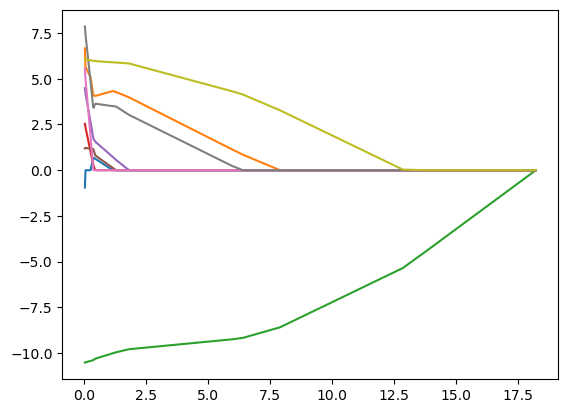

In [ ]:
# Chemin 1 : alpha issus de la grille automatique de LassoCV
# Chaque courbe représente l'évolution d'un coefficient en fonction de alpha
# On voit les variables entrer/sortir du modèle au fur et à mesure que alpha diminue
plt.plot(alphas, coefs_lasso)
plt.title("Chemin Lasso — grille automatique LassoCV")
plt.xlabel("alpha")
plt.ylabel("Coefficients")
plt.show()

In [ ]:
# Grille manuelle large : alpha de 0.1 à 100 (valeurs grandes → modèles très pénalisés)
alphas = np.arange(100) + 0.1
print(alphas)

[ 0.1  1.1  2.1  3.1  4.1  5.1  6.1  7.1  8.1  9.1 10.1 11.1 12.1 13.1
 14.1 15.1 16.1 17.1 18.1 19.1 20.1 21.1 22.1 23.1 24.1 25.1 26.1 27.1
 28.1 29.1 30.1 31.1 32.1 33.1 34.1 35.1 36.1 37.1 38.1 39.1 40.1 41.1
 42.1 43.1 44.1 45.1 46.1 47.1 48.1 49.1 50.1 51.1 52.1 53.1 54.1 55.1
 56.1 57.1 58.1 59.1 60.1 61.1 62.1 63.1 64.1 65.1 66.1 67.1 68.1 69.1
 70.1 71.1 72.1 73.1 74.1 75.1 76.1 77.1 78.1 79.1 80.1 81.1 82.1 83.1
 84.1 85.1 86.1 87.1 88.1 89.1 90.1 91.1 92.1 93.1 94.1 95.1 96.1 97.1
 98.1 99.1]


### Exploration manuelle de la grille d'alpha
On teste deux grilles manuelles pour voir si la plage automatique était bien calibrée.

In [52]:
coefs_lasso = []
Xcr = StandardScaler().fit(X).transform(X)
for a in alphas:
    ## lasso
    lasso = Lasso(alpha=a, warm_start=True).fit(Xcr, y)
    coefs_lasso.append(lasso.coef_)

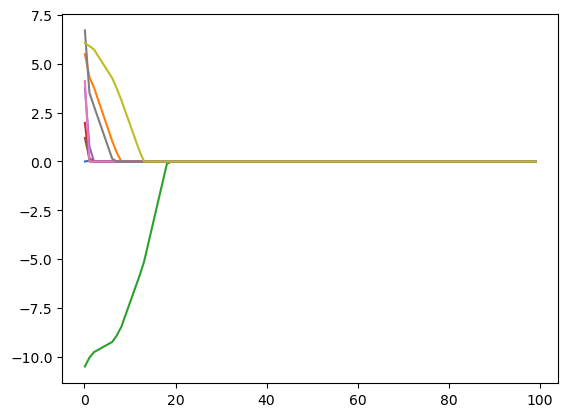

In [53]:
plt.plot(alphas,coefs_lasso)
plt.show()

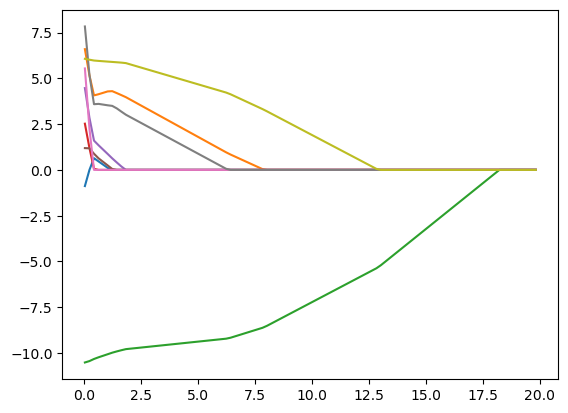

In [ ]:
# Grille manuelle fine : alpha de 0.02 à 20 (divisé par 5) → zoome sur la zone intéressante
alphas = (np.arange(100) + 0.1) / 5
coefs_lasso = []
Xcr = StandardScaler().fit(X).transform(X)
for a in alphas:
    lasso = Lasso(alpha=a, warm_start=True).fit(Xcr, y)
    coefs_lasso.append(lasso.coef_)
plt.plot(alphas, coefs_lasso)
plt.title("Chemin Lasso — grille fine (0.02 à 20)")
plt.xlabel("alpha")
plt.ylabel("Coefficients")
plt.show()

In [ ]:
# alpha = 7 : pénalité forte, presque tous les coefficients sont nuls (modèle très parcimonieux)
lasso = Lasso(alpha=7, warm_start=True).fit(Xcr, y)
lasso.coef_

array([ 0.        ,  0.50620504, -8.93837869, -0.        ,  0.        ,
        0.        , -0.        ,  0.        ,  3.79222761])

### Vérification avec des alpha spécifiques et comparaison avec statsmodels
On teste une valeur large (alpha=7, modèle très sparse) puis la valeur optimale trouvée par `LassoCV` (`alpha ≈ 2.095`), et on compare les variables retenues avec un modèle statsmodels classique.

In [57]:
ozone.describe()

,O3,T12,T15,Ne12,N12,S12,E12,W12,Vx,O3v
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.00000,50.000000
mean,86.300000,20.320000,21.390000,5.020000,0.940000,0.580000,1.360000,1.540000,-0.83120,84.280000
std,23.900824,4.674638,4.980544,2.535382,2.122859,1.499524,2.229304,2.451239,13.59233,24.953868
min,41.800000,7.900000,10.100000,0.000000,0.000000,0.000000,0.000000,0.000000,-27.06000,38.000000
25%,66.600000,17.400000,18.150000,3.000000,0.000000,0.000000,0.000000,0.000000,-10.80000,63.400000
50%,83.900000,19.750000,21.050000,6.000000,0.000000,0.000000,0.000000,0.000000,-3.25500,83.400000
75%,102.200000,24.325000,25.700000,7.000000,0.000000,0.000000,3.000000,2.750000,9.35000,102.750000
max,139.000000,29.500000,30.600000,8.000000,7.000000,6.000000,8.000000,8.000000,28.36000,142.800000


In [58]:
round(etape_lassocv.alpha_,4)

2.095

In [ ]:
# alpha optimal retenu par LassoCV (≈2.095) → variables retenues : coef_ != 0
lasso = Lasso(alpha=2.095, warm_start=True).fit(Xcr, y)
lasso.coef_

array([ 0.        ,  3.78210755, -9.75109259, -0.        ,  0.        ,
        0.        , -0.        ,  2.8276517 ,  5.72984736])

In [ ]:
# Validation : on ajuste un modèle statsmodels avec les variables sélectionnées par Lasso
# (T15, Ne12, Vx, O3v) pour comparer les p-values et coefficients avec les résultats sklearn
import statsmodels.formula.api as smf
reg = smf.ols('O3 ~ T15+Ne12+Vx+O3v', data=ozone).fit()
reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     O3   R-squared:                       0.732
Model:                            OLS   Adj. R-squared:                  0.708
Method:                 Least Squares   F-statistic:                     30.75
Date:                Tue, 17 Mar 2026   Prob (F-statistic):           2.35e-12
Time:                        11:08:12   Log-Likelihood:                -196.21
No. Observations:                  50   AIC:                             402.4
Df Residuals:                      45   BIC:                             412.0
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     61.8252     14.897      4.150      0.000      31.821      91.830
T15            1.0577      0.452      2.339      0.024       0.147       1.969
Ne12          -3.9935      1.007     -3.965      0.000      -6.022      -1.965
Vx             0.3146      0.161      1.957      0.057      -0.009       0.638
O3v            0.2629      0.092      2.853      0.007       0.077       0.449
==============================================================================
Omnibus:                        0.249   Durbin-Watson:                   1.831
Prob(Omnibus):                  0.883   Jarque-Bera (JB):                0.430
Skew:                          -0.116   Prob(JB):                        0.806
Kurtosis:                       2.609   Cond. No.                         739.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [62]:
pipe_lassocv.fit(X, y)
etape_lassocv = pipe_lassocv.named_steps["lassocv"]
etape_lassocv.alphas_

array([1.82214402e+01, 1.69933761e+01, 1.58480794e+01, 1.47799719e+01,
       1.37838513e+01, 1.28548658e+01, 1.19884909e+01, 1.11805068e+01,
       1.04269780e+01, 9.72423459e+00, 9.06885373e+00, 8.45764334e+00,
       7.88762649e+00, 7.35602686e+00, 6.86025527e+00, 6.39789702e+00,
       5.96670018e+00, 5.56456456e+00, 5.18953153e+00, 4.83977447e+00,
       4.51358987e+00, 4.20938902e+00, 3.92569029e+00, 3.66111190e+00,
       3.41436521e+00, 3.18424843e+00, 2.96964074e+00, 2.76949689e+00,
       2.58284207e+00, 2.40876716e+00, 2.24642431e+00, 2.09502283e+00,
       1.95382531e+00, 1.82214402e+00, 1.69933761e+00, 1.58480794e+00,
       1.47799719e+00, 1.37838513e+00, 1.28548658e+00, 1.19884909e+00,
       1.11805068e+00, 1.04269780e+00, 9.72423459e-01, 9.06885373e-01,
       8.45764334e-01, 7.88762649e-01, 7.35602686e-01, 6.86025527e-01,
       6.39789702e-01, 5.96670018e-01, 5.56456456e-01, 5.18953153e-01,
       4.83977447e-01, 4.51358987e-01, 4.20938902e-01, 3.92569029e-01,
      

In [64]:
enetcv = ElasticNetCV(cv=10, random_state=0)
pipe_enetcv = Pipeline(steps=[("cr", cr), ("enetcv", enetcv)])
pipe_enetcv.fit(X, y)
etape_enetcv = pipe_enetcv.named_steps["enetcv"]
etape_enetcv.alphas_

array([36.44288041, 33.98675224, 31.69615889, 29.55994387, 27.56770258,
       25.7097317 , 23.97698183, 22.3610135 , 20.85395603, 19.44846919,
       18.13770746, 16.91528668, 15.77525297, 14.71205372, 13.72051054,
       12.79579405, 11.93340036, 11.12912911, 10.37906306,  9.67954894,
        9.02717974,  8.41877804,  7.85138058,  7.3222238 ,  6.82873043,
        6.36849685,  5.93928148,  5.53899378,  5.16568414,  4.81753432,
        4.49284863,  4.19004567,  3.90765061,  3.64428804,  3.39867522,
        3.16961589,  2.95599439,  2.75677026,  2.57097317,  2.39769818,
        2.23610135,  2.0853956 ,  1.94484692,  1.81377075,  1.69152867,
        1.5775253 ,  1.47120537,  1.37205105,  1.2795794 ,  1.19334004,
        1.11291291,  1.03790631,  0.96795489,  0.90271797,  0.8418778 ,
        0.78513806,  0.73222238,  0.68287304,  0.63684969,  0.59392815,
        0.55389938,  0.51656841,  0.48175343,  0.44928486,  0.41900457,
        0.39076506,  0.3644288 ,  0.33986752,  0.31696159,  0.29

# Partie 3 — Exploration de la régression logistique (données SAh)
**Données** : `SAh.csv` — cohorte d'hommes sud-africains, cible = `chd` (maladie cardiaque, 0/1)  
**Plan** :
1. Modèle GLM complet (statsmodels) → sélection backward manuelle par suppression successive
2. Sélection automatique via `choixglmstats.bestglm` (BIC et AIC)
3. Comparaison avec `LogisticRegression` sklearn
4. Analyse des probabilités prédites et choix du seuil de classification

In [ ]:
import pandas as pd
don = pd.read_csv("https://regression-avec-python.github.io/donnees/SAh.csv", header=0, sep=",")
don.describe(include='all')  # 462 observations, 10 variables (9 prédicteurs + chd)

,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,chd
count,462.000000,462.000000,462.000000,462.000000,462,462.000000,462.000000,462.000000,462.000000,462.000000
unique,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,Absent,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,270,NaN,NaN,NaN,NaN,NaN
mean,138.326840,3.635649,4.740325,25.406732,NaN,53.103896,26.044113,17.044394,42.816017,0.346320
std,20.496317,4.593024,2.070909,7.780699,NaN,9.817534,4.213680,24.481059,14.608956,0.476313
min,101.000000,0.000000,0.980000,6.740000,NaN,13.000000,14.700000,0.000000,15.000000,0.000000
25%,124.000000,0.052500,3.282500,19.775000,NaN,47.000000,22.985000,0.510000,31.000000,0.000000
50%,134.000000,2.000000,4.340000,26.115000,NaN,53.000000,25.805000,7.510000,45.000000,0.000000
75%,148.000000,5.500000,5.790000,31.227500,NaN,60.000000,28.497500,23.892500,55.000000,1.000000


In [31]:
import statsmodels.formula.api as smf
import statsmodels.api as sm
form ="chd ~ " + "+".join(don.columns[ :-1 ])
print(form)
#mod = smf.glm('chd~ sbp +tobacco', data=don, family=sm.families.Binomial()).fit()
mod = smf.glm(form, data=don, family=sm.families.Binomial()).fit()
mod.summary()
print("AIC:", mod.aic)

chd ~ sbp+tobacco+ldl+adiposity+famhist+typea+obesity+alcohol+age
AIC: 492.14003237249784


### 3.1 — Modèle GLM complet et sélection backward manuelle
On démarre avec toutes les variables, puis on retire une à une la variable la moins significative (p-value la plus élevée), en vérifiant que l'AIC diminue à chaque étape.

In [32]:
mod = smf.glm('chd ~ sbp+tobacco+ldl+adiposity+famhist+typea+obesity+alcohol+age', data=don, family=sm.families.Binomial()).fit()
mod.summary()
print("AIC:", mod.aic)

AIC: 492.14003237249784


In [33]:
mod = smf.glm('chd ~ sbp+tobacco+ldl+adiposity+famhist+typea+obesity+age', data=don, family=sm.families.Binomial()).fit()
mod.summary()
print("AIC:", mod.aic)

AIC: 490.140768659557


In [34]:
mod = smf.glm('chd ~ sbp+tobacco+ldl+famhist+typea+obesity+age', data=don, family=sm.families.Binomial()).fit()
mod.summary()
print("AIC:", mod.aic)

AIC: 488.5489645288282


In [35]:
mod = smf.glm('chd ~ tobacco+ldl+famhist+typea+obesity+age', data=don, family=sm.families.Binomial()).fit()
mod.summary()
print("AIC:", mod.aic)

AIC: 487.979893906008


In [36]:
mod = smf.glm('chd ~ tobacco+ldl+famhist+typea+age', data=don, family=sm.families.Binomial()).fit()
mod.summary()
print("AIC:", mod.aic)

AIC: 487.6855780337486


In [37]:
mod = smf.glm('chd ~ tobacco+ldl+famhist+typea', data=don, family=sm.families.Binomial()).fit()
mod.summary()
print("AIC:", mod.aic)

AIC: 512.3788298107636


In [40]:
import logistic_step_sk
import choixglmstats

### 3.2 — Sélection automatique via `choixglmstats.bestglm`
`bestglm` teste **toutes** les combinaisons de variables possibles et classe les modèles par AIC et BIC. C'est une recherche exhaustive (2^p modèles testés).

In [43]:
mod_sel = choixglmstats.bestglm(don, upper=form)
print(mod_sel.sort_values(by=["BIC","nb_var"]).iloc[:5,[1,3]])

                                        var_added         BIC
175           (typea, tobacco, age, famhist, ldl)  512.498967
282                (typea, tobacco, age, famhist)  515.392160
357                  (tobacco, age, famhist, ldl)  516.121685
302                    (typea, age, famhist, ldl)  516.710029
92   (typea, tobacco, age, famhist, ldl, obesity)  516.928848


In [44]:
print(mod_sel.sort_values(by=["AIC","nb_var"]).iloc[:5,[1,2]])

                                             var_added         AIC
175                (typea, tobacco, age, famhist, ldl)  487.685578
92        (typea, tobacco, age, famhist, ldl, obesity)  487.979894
36   (typea, tobacco, age, famhist, ldl, sbp, obesity)  488.548965
91            (typea, tobacco, age, famhist, ldl, sbp)  488.654793
81      (typea, tobacco, adiposity, age, famhist, ldl)  489.443466


In [48]:
nomsvar = list(don.columns.difference(["chd"]))
#design matrix
formule = "~" + "+".join(nomsvar)
dsX = dmatrix(formule,don)
X = np.asarray(dsX)[:,1:]
Y = don["chd"].to_numpy()

### 3.3 — Comparaison avec `LogisticRegression` sklearn
On reconstruit X et Y avec `dmatrix` (même encodage que pour statsmodels) puis on ajuste un `LogisticRegression` (régularisation L2 par défaut, `C=1`).  
> **Note** : les coefficients sklearn ne sont pas directement comparables aux coefficients statsmodels car sklearn pénalise par défaut.

In [49]:
from sklearn.linear_model import LogisticRegression

In [56]:
reglog = LogisticRegression().fit(X,Y)
print(reglog.intercept_)
reglog.coef_

[-0.35091483]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array([[ 9.71264252e-01,  7.32242570e-02,  2.64973947e-02,
        -7.38695980e-04,  1.43558781e-01, -1.75961771e-01,
        -5.59305397e-03,  8.05300324e-02,  1.07192698e-02]])

In [55]:
mod = smf.glm(form, data=don, family=sm.families.Binomial()).fit()
mod.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                    chd   No. Observations:                  462
Model:                            GLM   Df Residuals:                      452
Model Family:                Binomial   Df Model:                            9
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -236.07
Date:                Tue, 17 Mar 2026   Deviance:                       472.14
Time:                        16:56:09   Pearson chi2:                     452.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.2353
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -6.1507      1.308     -4.701      0.000      -8.715      -3.587
famhist[T.Present]     0.9254      0.228      4.061      0.000       0.479       1.372
sbp                    0.0065      0.006      1.135      0.256      -0.005       0.018
tobacco                0.0794      0.027      2.984      0.003       0.027       0.132
ldl                    0.1739      0.060      2.915      0.004       0.057       0.291
adiposity              0.0186      0.029      0.635      0.526      -0.039       0.076
typea                  0.0396      0.012      3.214      0.001       0.015       0.064
obesity               -0.0629      0.044     -1.422      0.155      -0.150       0.024
alcohol                0.0001      0.004      0.027      0.978      -0.009       0.009
age                    0.0452      0.012      3.728      0.000       0.021       0.069
======================================================================================
"""

In [62]:
Xnew =X[[1,407,34],]
print(Xnew)
reglog.predict(Xnew)

[[0.000e+00 2.861e+01 6.300e+01 2.060e+00 4.410e+00 2.887e+01 1.440e+02
  1.000e-02 5.500e+01]
 [1.000e+00 4.060e+01 6.000e+01 3.600e+01 4.430e+00 3.204e+01 2.000e+02
  1.920e+01 5.500e+01]
 [0.000e+00 2.531e+01 4.800e+01 3.600e+00 7.100e+00 2.984e+01 1.480e+02
  5.500e+00 5.600e+01]]


array([0, 1, 0], dtype=int64)

In [63]:
reglog.predict_proba(Xnew)

array([[0.77731915, 0.22268085],
       [0.23653325, 0.76346675],
       [0.77632946, 0.22367054]])

In [ ]:
pest = reglog.predict_proba(X)[:, 1]  # probabilité prédite d'appartenir à la classe 1 (chd=1)
print(pest)

[6.42469865e-01 2.22680852e-01 3.71921296e-01 6.02293268e-01
 6.96067182e-01 5.97201176e-01 2.36514947e-01 5.42228120e-01
 2.44261079e-01 4.56984805e-01 3.47335092e-01 7.26499984e-01
 6.19367496e-02 5.75113468e-02 5.50222252e-01 3.95445231e-01
 7.01833091e-01 7.10870711e-01 6.48716052e-01 7.91298524e-01
 1.16085553e-01 4.89565319e-01 7.03519528e-01 2.03531960e-01
 5.24749009e-01 8.72776643e-01 1.71985030e-01 7.07889401e-01
 5.46035749e-01 2.75110830e-01 3.60706653e-01 3.81946041e-01
 7.47611734e-01 3.46676589e-01 2.23670536e-01 2.29573259e-01
 1.93955385e-01 1.94043929e-01 2.45982355e-01 7.99171807e-01
 3.92091191e-01 1.18671165e-01 6.34644579e-02 3.63427129e-01
 8.99222002e-04 3.42023082e-01 7.38305268e-01 3.30925422e-01
 7.73983539e-02 1.38117883e-01 3.83286775e-01 2.57862501e-01
 2.82436969e-01 3.57193431e-01 2.88464494e-01 4.53015590e-01
 8.89928643e-02 2.34556532e-01 1.21437272e-01 5.77931282e-01
 1.18939010e-01 5.04301044e-01 6.55143102e-01 1.13916147e-01
 5.33990184e-02 6.142537

In [ ]:
pesto = np.sort(pest)  # probabilités triées par ordre croissant (pour trouver le seuil naturel)

### 3.4 — Analyse des probabilités prédites et choix du seuil naturel
Par défaut sklearn classe à seuil 0.5, mais le **seuil naturel** = proportion d'événements dans les données (`Y=1`).  
Ici : 302 individus sur 462 ont `chd=0`, donc ~34% ont `chd=1` → le seuil naturel sera autour de 0.34.

In [ ]:
sum(pest > 0.5)  # nb d'individus classés chd=1 avec le seuil par défaut 0.5

125

In [ ]:
sum(Y > 0.5)  # nb réel de chd=1 dans les données → valeur cible à atteindre avec le bon seuil

160

In [77]:
sum(Y<0.5)

302

In [78]:
pesto[302]

0.432322294780402

In [ ]:
# Seuil naturel : pesto trié, on prend la probabilité à la position "nb chd=0"
# → les individus au-dessus de ce seuil = les 160 cas positifs (même proportion que dans les données)
srp = pesto[301:302].mean()  # position 302 ≈ nb de chd=0 (302 individus avec chd=0)

In [ ]:
sum(pest > srp)  # nb classés chd=1 avec le seuil naturel → doit être ≈ 160 (nb réel de chd=1)

160

In [ ]:
print(srp)  # valeur du seuil naturel (attendu autour de 0.33–0.35 selon la proportion de chd=1)

0.4293596324006116
